## Notebook 03: CNN Experiments

Trains a convolutional neural network (3 conv blocks with BatchNorm, ReLU, MaxPool,
and Dropout2d, followed by a fully-connected classifier head) on CIFAR-10, compares
its performance against the MLP baseline from notebook 02, and visualizes intermediate
feature maps to observe how representations evolve across layers.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/cifar10-mlp-vs-cnn/notebooks')

os.makedirs('../results/figures', exist_ok=True)

metrics_path = '../results/metrics.json'

[CNN] Epoch 01/20 | Loss: 1.6774 | Train Acc: 37.84% | Val Acc: 51.90%
[CNN] Epoch 05/20 | Loss: 0.9796 | Train Acc: 65.77% | Val Acc: 71.98%
[CNN] Epoch 10/20 | Loss: 0.7198 | Train Acc: 75.09% | Val Acc: 78.00%
[CNN] Epoch 15/20 | Loss: 0.5759 | Train Acc: 80.10% | Val Acc: 80.94%
[CNN] Epoch 20/20 | Loss: 0.5179 | Train Acc: 81.94% | Val Acc: 81.62%
CNN test accuracy: 82.01%


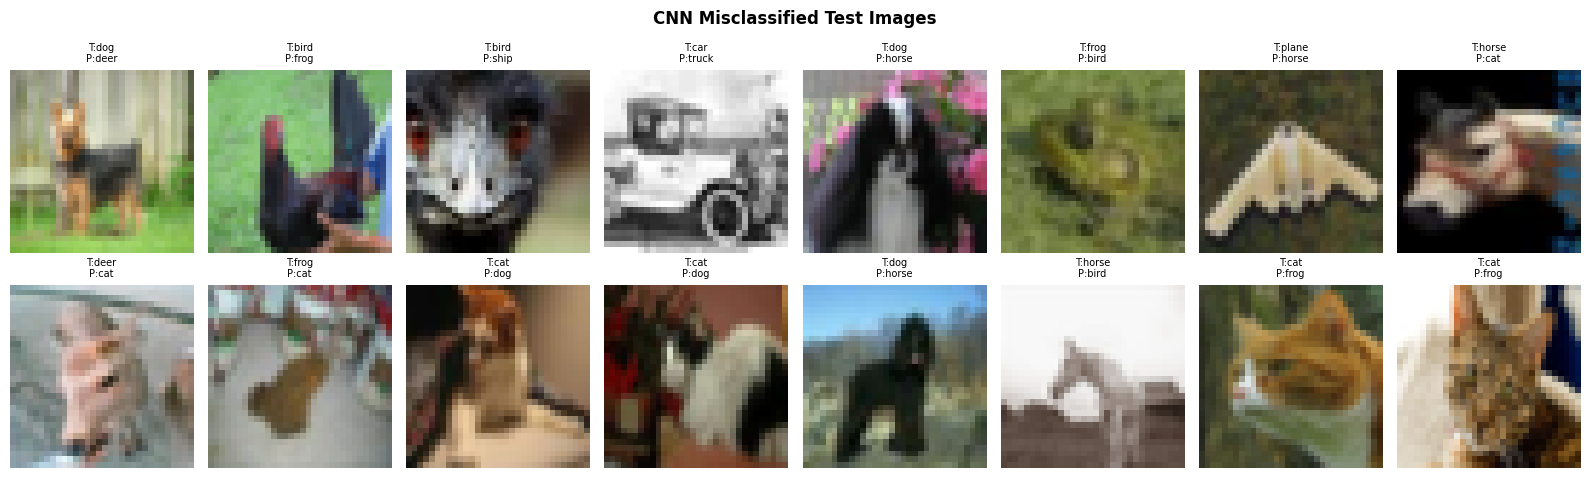

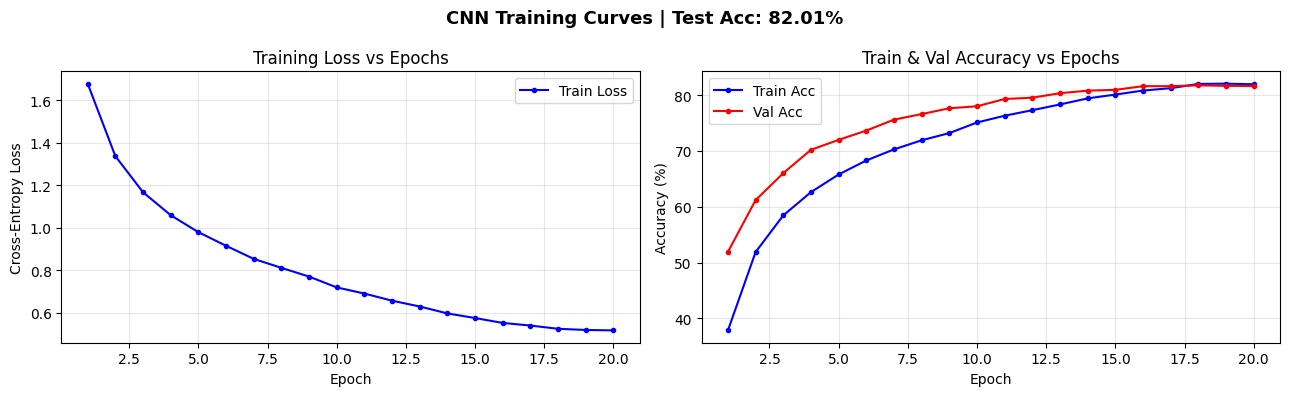

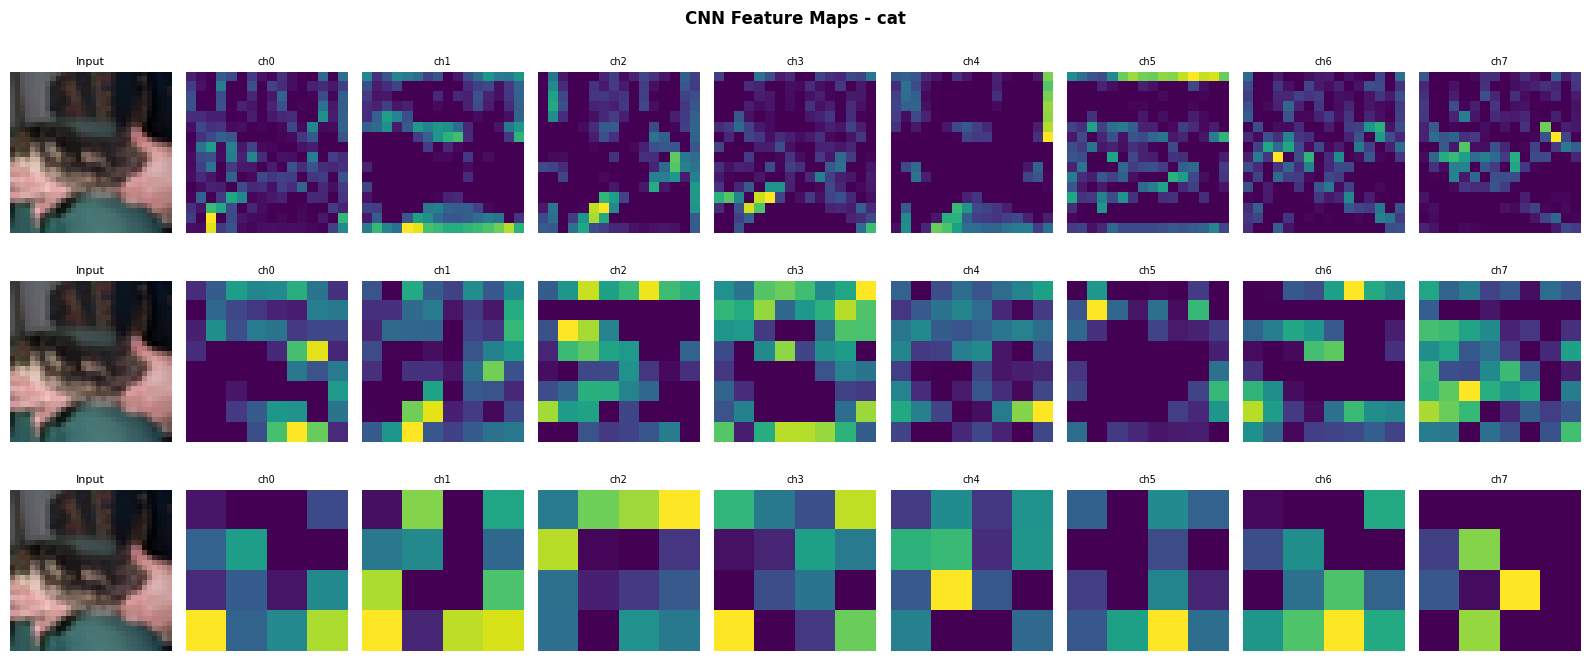

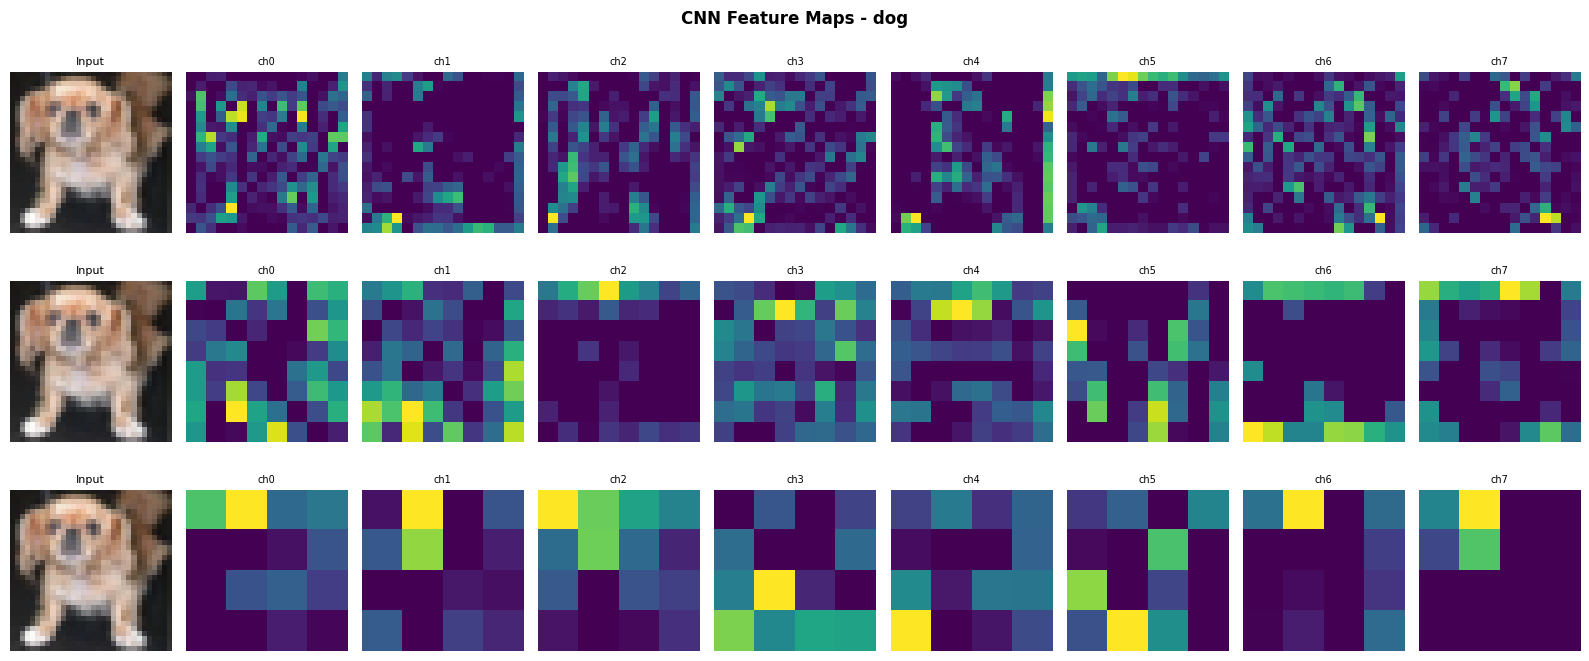

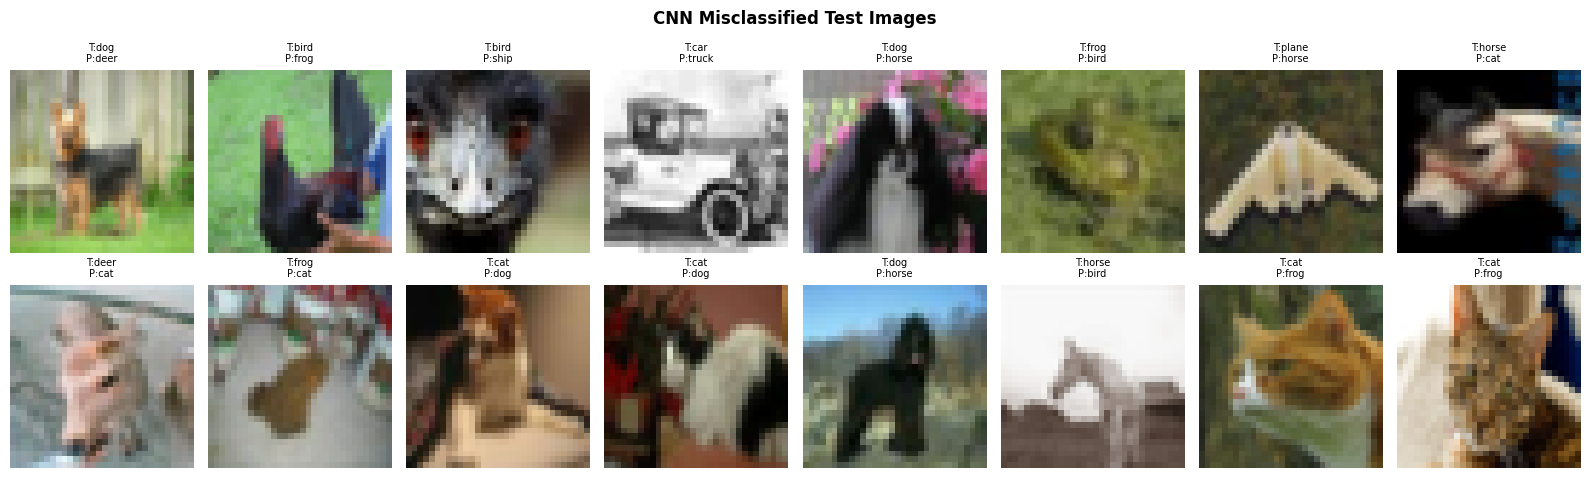

In [ ]:
from pathlib import Path
import json
import sys
import os
import torch

sys.path.append(str(Path.cwd().parent / 'src'))

from data import get_dataloaders
from models import CNN
from train import train_model, evaluate, count_parameters, get_misclassified
from visualize import plot_history, visualize_feature_maps, visualize_misclassified

trainloader, valloader, testloader, _, _, _ = get_dataloaders()
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

cnn_model = CNN(use_pooling=True)
cnn_history = train_model(cnn_model, trainloader, valloader, epochs=20, label='CNN')
cnn_test_acc = evaluate(cnn_model, testloader)
print(f'CNN test accuracy: {cnn_test_acc:.2f}%')
plot_history(cnn_history, title=f'CNN Training Curves | Test Acc: {cnn_test_acc:.2f}%', save_path='../results/figures/cnn_training_curves.png')
torch.save(cnn_model.state_dict(), '../results/cnn_model.pt')

dataiter = iter(trainloader)
images, labels = next(dataiter)
for idx in [0, 3]:
    visualize_feature_maps(cnn_model, images[idx], title=f'CNN Feature Maps - {classes[labels[idx]]}', save_path=f'../results/figures/cnn_feature_map_{idx}.png')

mis_imgs, mis_true, mis_pred = get_misclassified(cnn_model, testloader, n=16)
visualize_misclassified(mis_imgs, mis_true, mis_pred, classes, title='CNN Misclassified Test Images', save_path='../results/figures/cnn_misclassified.png')



In [ ]:
metrics = {}
if os.path.exists(metrics_path):
    with open(metrics_path) as f:
        metrics = json.load(f)

metrics.update({
    'cnn_test_accuracy': round(float(cnn_test_acc), 2),
    'cnn_parameters': count_parameters(cnn_model),
})

with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved CNN metrics to ../results/metrics.json')

Saved CNN metrics to ../results/metrics.json


In [ ]:
torch.save(cnn_model.state_dict(), '../results/cnn_model.pt')

### CNN Results — Comparison with MLP

The CNN achieves **82.01% test accuracy** with only **1,342,122 parameters**. Compared
to the MLP baseline from notebook 02 (**57.40% test accuracy**, 3,805,450 parameters),
the CNN uses nearly **2.8× fewer parameters** while outperforming it by **~24.6
percentage points**.

Training behavior also looks markedly healthier: training accuracy (81.94%) and
validation accuracy (81.62%) track closely throughout training, with only a ~0.3-point
gap by epoch 20 — in sharp contrast to the MLP baseline's ~13-point train/val gap. This
indicates the CNN generalizes far better despite (or rather, *because of*) having fewer
parameters: its convolutional structure encodes a useful prior (local connectivity,
weight sharing, translation equivariance) that the MLP must instead try to learn from
scratch, and largely fails to.

**Why this happens**: convolutional filters are shared across every spatial location in
an image, so the network doesn't need separate weights to recognize the same edge or
texture pattern wherever it appears. An MLP, by contrast, assigns independent weights to
every one of its 3072 input pixels, with no mechanism to exploit the fact that nearby
pixels are typically correlated. This is the core reason a 2.8×-smaller CNN substantially
outperforms a much larger fully-connected network on image data.

*(MLP figures above are reported from notebook 02's saved results; the MLP model itself
is not re-loaded here since this notebook focuses on the CNN.)*

### Feature Map Evolution Across Layers

The visualized feature maps (8 of the available channels shown per block) reveal a
clear hierarchy:

- **Block 1** (32 channels, 16×16 after pooling): activations resemble simple edge and
  color-contrast detectors — responses are still visually close to the raw input, picking
  out boundaries and broad regions of contrast.
- **Block 2** (64 channels, 8×8 after pooling): patterns become more abstract — activations
  highlight larger structural regions (e.g. body shapes, background/foreground separation)
  rather than fine edges.
- **Block 3** (128 channels, 4×4 after pooling): at this resolution, individual channels are
  hard to interpret visually, but they encode high-level, class-discriminative information —
  this is the representation the classifier head ultimately uses to separate the 10 classes.

This progression — from low-level, locally-interpretable features in early layers to
increasingly abstract, spatially-coarse representations in deeper layers — is the
expected behavior of a CNN and is fundamentally unavailable to an MLP, which has no
layer-wise spatial structure to build this hierarchy on top of.

*(Note: only 8 of 32/64/128 channels per block are shown — a representative sample by
channel index, not a hand-picked selection.)*

### Misclassified Images (CNN)

Compared to the MLP's misclassifications, the CNN's errors are fewer in absolute number
(reflecting its much higher overall accuracy) and tend to cluster around genuinely
ambiguous cases — classes that are visually or semantically close (e.g. cat/dog,
automobile/truck) or images with unusual poses, occlusion, or atypical backgrounds. This
is consistent with a model that has learned real structural/object-level features rather
than coarse color statistics, unlike the MLP.